In [1]:
#2021.08.18. WED
#Team_밥믈리에
 
## K-means Clustering
#00. 패키지 호출
import warnings 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')

#00-2. 시각화 옵션 설정하기.  
%matplotlib inline
#mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = 'D2Coding'

#00-3. 사전변수 정의하기. 
RANGE = [2, 3, 4, 5, 6, 7, 8]

In [2]:
#01. 데이터셋 호출 및 전처리하기. 
#(1) 데이터셋 불러오기
cultivar_dataset = pd.read_excel('../data/nlp/cultivar_indicator_scaling_backup.xlsx')

#(2) 데이터셋의 cultivar 컬럼 인덱스로 설정하기. 
#cultivar_dataset.rename(columns={'Unnamed: 0':'indicator', '숙기_numbering':'숙기'}, inplace=True)
cultivar_dataset.set_index('품종', inplace=True)

#(3) 결과 확인하기. 
cultivar_dataset

,고소하다,달다,담백하다,고들하다,촉촉하다,부드럽다,쫀득하다,찰지다,숙기
품종,,,,,,,,,
count_고시히카리,0.037939,0.356117,0.010580,0.660280,0.448990,0.040249,0.937351,0.564821,0.0
count_골드퀸,1.000000,0.851098,1.000000,0.216699,0.325048,0.020497,0.576809,0.446231,0.5
count_밀키퀸,0.155891,0.679992,0.173870,0.000000,0.000000,0.114043,0.000000,0.997257,0.0
count_삼광,0.046862,0.272294,0.016275,0.530439,0.257319,0.064051,0.675921,0.533797,1.0
count_새청무,0.107694,0.225371,0.000000,1.000000,1.000000,0.000000,0.887267,0.538501,1.0
count_신동진,0.055278,0.250513,0.013854,0.564385,0.435897,0.042026,0.615296,0.699072,1.0
count_영호진미,0.036125,0.000000,0.013716,0.665772,0.399463,0.061175,1.000000,1.000000,1.0
count_오대,0.026702,0.208586,0.021524,0.360697,0.343284,0.024706,0.711800,0.530838,0.0
count_일품,0.063979,0.150159,0.031230,0.433121,0.389809,0.027312,0.528404,0.756928,1.0


In [3]:
#(4) TEST 01 
# scaler = MinMaxScaler()
# cultivar_dataset[['프로틴_scaling','아밀로스_scaling']] = scaler.fit_transform(cultivar_dataset[['프로틴_함량','아밀로스_함량']])
# cultivar_dataset = cultivar_dataset.drop(['프로틴_함량', '아밀로스_함량'], axis=1)
# cultivar_dataset

In [4]:
#02. 데이터셋 PCA 처리하기.  
#(1) 주성분 분석을 통해 2차원으로 축소하기. 
pca = PCA(n_components=2, random_state=2021)
cultivar_dataset_pca = pca.fit_transform(cultivar_dataset)
cultivar_dataset_pca = pd.DataFrame(cultivar_dataset_pca, columns=['PC1','PC2'], index=cultivar_dataset.index)
cultivar_dataset_pca['PC2'] = cultivar_dataset_pca['PC2']*-1
cultivar_dataset_pca

,PC1,PC2
품종,,
count_고시히카리,0.167236,-0.265056
count_골드퀸,0.922808,0.851463
count_밀키퀸,0.981804,-0.085825
count_삼광,-0.291737,0.082969
count_새청무,-0.726630,0.162671
count_신동진,-0.354202,0.143741
count_영호진미,-0.638837,0.217295
count_오대,0.322949,-0.317243
count_일품,-0.304990,0.152344


In [5]:
#(2) PCA component 확인하기.
pca_component = pd.DataFrame(pca.components_, columns=cultivar_dataset.columns)
pca_component.iloc[1, :] = pca_component.iloc[1, :] * -1
pca_component

,고소하다,달다,담백하다,고들하다,촉촉하다,부드럽다,쫀득하다,찰지다,숙기
0,0.249413,0.409088,0.292453,-0.406905,-0.229015,0.033498,-0.294862,-0.105117,-0.606447
1,0.425819,0.260001,0.410892,-0.150413,0.094399,-0.464222,0.198432,0.326127,0.435286


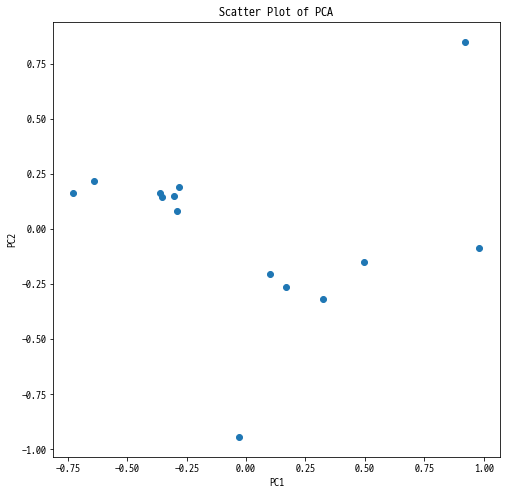

In [6]:
#(3) PCA 처리값을 기반으로 시각화하기. 
plt.figure(figsize=(8,8))
plt.title('Scatter Plot of PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.scatter(x=cultivar_dataset_pca['PC1'], y=cultivar_dataset_pca['PC2'])
plt.show()

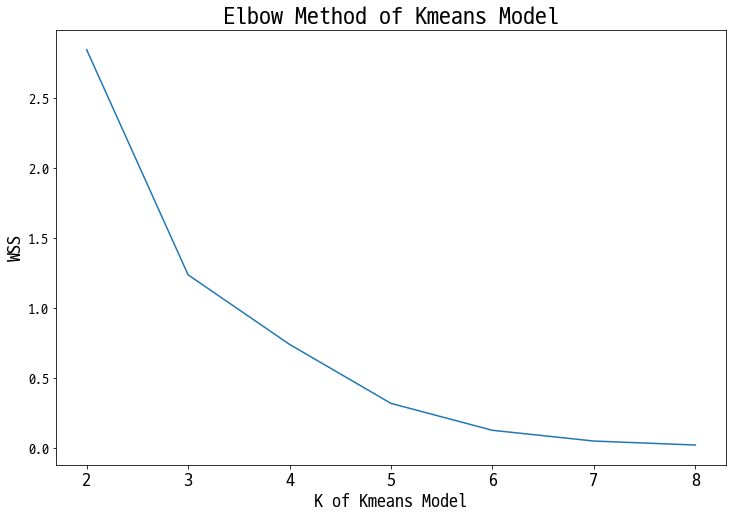

In [10]:
#03-1. 최적 k 값 파악을 위한 엘보우 포인트 파악하기.
#(1) k 값에 따른 inertia(WSS) 값 수집하기. 
inertia_list = []

for k in RANGE :
    kmeans_model = KMeans(n_clusters=k, random_state=2021)
    kmeans_model.fit(cultivar_dataset_pca)
    inertia = kmeans_model.inertia_
    inertia_list.append(inertia)

#(2) 시각화하기.
plt.figure(figsize=(12,8))
plt.title('Elbow Method of Kmeans Model', fontsize=24)
plt.xlabel('K of Kmeans Model', fontsize=18)
plt.ylabel('WSS', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=14)

plt.plot(RANGE, inertia_list)
plt.show()

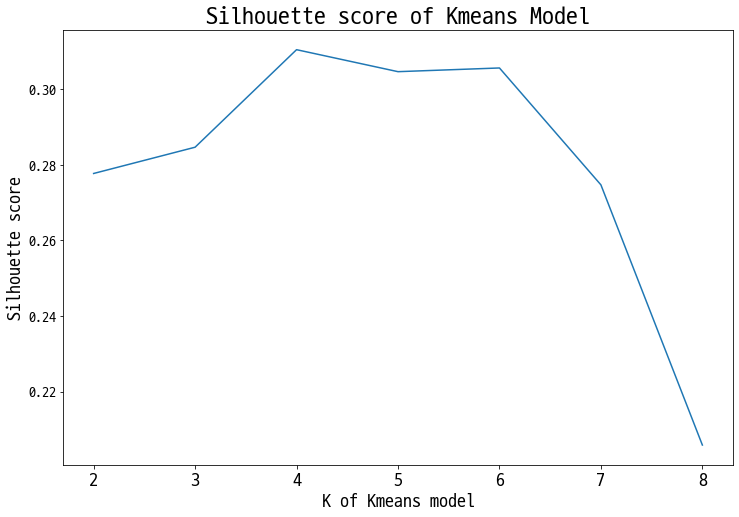

In [9]:
#03-2. 최적 k값 파악을 위한 실루엣계수 파악하기. 
#(1) k 값에 따른 silhouette_score 값 수집하기. 
silh_score_list = []

for k in RANGE :
    kmeans_model = KMeans(n_clusters=k, random_state=2021)
    silh_score = silhouette_score(cultivar_dataset.iloc[:,:12], kmeans_model.fit_predict(cultivar_dataset))
    silh_score_list.append(silh_score)

#(2) 시각화하기. 
plt.figure(figsize=(12,8))
plt.title('Silhouette score of Kmeans Model', fontsize=24)
plt.xlabel('Number of Cluster', fontsize=18)
plt.ylabel('Silhouette score', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=14)

plt.plot(RANGE, silh_score_list)
plt.show()

In [ ]:
#04. k_means 모델로 군집화하기. 
#(1) 객체 정의하기. 
k_means_model = KMeans(n_clusters=4, random_state=2021)

#(2) 데이터셋에 군집 번호 컬럼 추가하기. 
cultivar_dataset_pca['cluster_num'] = k_means_model.fit_predict(cultivar_dataset_pca)

#(3) 군집화 결과 시각화하기. 
plt.figure(figsize=(8,8))
plt.title('K-means', fontsize=28)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.scatter(
    x=cultivar_dataset_pca['PC1'], 
    y=cultivar_dataset_pca['PC2'], 
    c=cultivar_dataset_pca['cluster_num'],
)
plt.show()